In [1]:
# Téléchargement et ouverture des données GTFS IDFM
import download_data
import pandas as pd

file_names = download_data.get_IDFM_data_path()
print(file_names.keys())

# open only usefull df :
usefull_keys = ["routes", "trips", "stop_times", "stops", "calendar"]

idfm = {k: pd.read_csv(f) for k, f in file_names.items() if k in usefull_keys}

Dossier cache trouvé, pas de téléchargement.
None
dict_keys(['calendar', 'stop_times', 'pathways', 'ticketing_deep_links', 'object_codes_extension', 'transfers', 'trips', 'routes', 'booking_rules', 'calendar_dates', 'stops', 'stop_extensions', 'agency'])


/tmp/ipykernel_37289/666018740.py:11: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  idfm = {k: pd.read_csv(f) for k, f in file_names.items() if k in usefull_keys}
/tmp/ipykernel_37289/666018740.py:11: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  idfm = {k: pd.read_csv(f) for k, f in file_names.items() if k in usefull_keys}


In [2]:
# Affichage des dataframes
for name, df in idfm.items():
    print(f"=== {name} ===")
    print(df.shape)
    print(df.head(3).to_string(index=False))
    print()

=== calendar ===
(1012, 10)
service_id  monday  tuesday  wednesday  thursday  friday  saturday  sunday  start_date  end_date
    IDFM:1       1        1          1         1       1         1       1    20251128  20251227
 IDFM:1029       1        1          1         0       1         0       0    20251222  20251226
 IDFM:1031       0        0          0         1       0         0       0    20251225  20251225

=== stop_times ===
(10278493, 14)
                           trip_id arrival_time departure_time  start_pickup_drop_off_window  end_pickup_drop_off_window    stop_id  stop_sequence  pickup_type  drop_off_type  local_zone_id  stop_headsign  timepoint pickup_booking_rule_id drop_off_booking_rule_id
IDFM:stif:local-175995-C00563-6002     13:28:00       13:28:00                           NaN                         NaN IDFM:10219              0            0              1            NaN            NaN          1                    NaN                      NaN
IDFM:stif:local-17599

# Traitement

In [3]:
# on remplace stop_id par parent_station pour les arrêts parents dans stop_times et stops
# le but est d'obtenir une ligne par arret commercial (initialement: la gare de bus et la gare RER d'un même arret partagent le même nom d'arret commercial mais ont des stop_id différents)

print(f"unique stop_id before replacement: {idfm['stops']['stop_id'].nunique()} in stops, {idfm['stop_times']['stop_id'].nunique()} in stop_times")

# les arrets parents n'ont pas de parent_station, on remplace les NA par leur propre stop_id
nb_na_before = idfm["stops"]["parent_station"].isna().sum()
idfm["stops"].fillna({"parent_station": idfm["stops"]["stop_id"]}, inplace=True)
print(f"NA parent_station : before {nb_na_before}, after {idfm['stops']['parent_station'].isna().sum()}")

# on remplace stop_id par parent_station dans stop_times
idfm["stop_times"] = idfm["stop_times"].merge(
    idfm["stops"][["stop_id", "parent_station"]], on="stop_id", how="left"
).drop(columns=["stop_id"]).rename(columns={"parent_station": "stop_id"})

# on ne conserve que les arrêts parents dans stops
idfm["stops"] = idfm["stops"][idfm["stops"]["parent_station"] == idfm["stops"]["stop_id"]].reset_index(drop=True)


print(f"unique stop_id after replacement: {idfm['stops']['stop_id'].nunique()} in stops, {idfm['stop_times']['stop_id'].nunique()} in stop_times")

unique stop_id before replacement: 53630 in stops, 35588 in stop_times
NA parent_station : before 15373, after 0
unique stop_id after replacement: 15373 in stops, 15373 in stop_times


In [4]:
# On ne conserve que les services ayant un jour donné pour calculer un nombre de trajet sur une journée en semaine


# on prend le prochain lundi à partir d'aujourd'hui au format YYYYMMDD
from datetime import datetime, timedelta
today = datetime.today()
next_monday = today + timedelta(days=(7 - today.weekday()) % 7)
next_monday_str = next_monday.strftime("%Y%m%d")
print(f"Travail avec le jour: {next_monday_str}")

next_monday_str = "20251201"  # reproductibilité # TODO :


print(len(idfm["calendar"][(idfm["calendar"]["monday"] == 1)]))
print(len(idfm["calendar"][(idfm["calendar"]["monday"] == 1) & (idfm["calendar"]["start_date"] <= int(next_monday_str)) & (idfm["calendar"]["end_date"] >= int(next_monday_str)) ]))
services_one_day = idfm["calendar"][(idfm["calendar"]["monday"] == 1) & (idfm["calendar"]["start_date"] <= int(next_monday_str)) & (idfm["calendar"]["end_date"] >= int(next_monday_str)) ]["service_id"]
trips_one_day = idfm["trips"].merge(services_one_day, on="service_id", how="inner")
print(f"Redution du nombre de trajets en ne conservant qu'un jour : {len(idfm['trips'])} -> {len(trips_one_day)}")

Travail avec le jour: 20251201
493
358
Redution du nombre de trajets en ne conservant qu'un jour : 461892 -> 143387


In [5]:
# Pour chaque stop_id, et chaque route_id, on calcul le nombre d'arrets par jour à ce stop
# voir le pdf docu_gtfs.pdf, section 3.4.5 page 17 pour la structure des tables
stop_times_one_day = idfm["stop_times"].merge(trips_one_day[["trip_id", "route_id"]], on="trip_id", how="inner")
stop_route_counts = stop_times_one_day.groupby(["stop_id", "route_id"]).size().reset_index(name="nb_stops_per_day")
print(f"Nombre de paires (stop_id, route_id) uniques le sur le jour {next_monday_str} : {len(stop_route_counts)}")
print(stop_route_counts.head(10).to_string(index=False))

Nombre de paires (stop_id, route_id) uniques le sur le jour 20251201 : 42119
    stop_id    route_id  nb_stops_per_day
IDFM:411281 IDFM:C01843               284
IDFM:411284 IDFM:C01843               284
IDFM:411318 IDFM:C01746                37
IDFM:411327 IDFM:C01737                27
IDFM:411330 IDFM:C01737                27
IDFM:411333 IDFM:C01737                27
IDFM:411336 IDFM:C01559                 8
IDFM:411339 IDFM:C01739                19
IDFM:411343 IDFM:C01739                19
IDFM:411346 IDFM:C01739                29


In [6]:
# on ajoute les infos des arrêts
stop_route_counts = (stop_route_counts.merge(idfm["stops"][["stop_id", "stop_name", "stop_lat", "stop_lon", "zone_id"]], on="stop_id", how="left")
                      .merge(idfm["routes"][["route_id", "route_short_name", "route_type", "route_color"]], on="route_id", how="left")
)
stop_route_counts.head(10)

,stop_id,route_id,nb_stops_per_day,stop_name,stop_lat,stop_lon,zone_id,route_short_name,route_type,route_color
0,IDFM:411281,IDFM:C01843,284,Lycée Henri Sellier,48.916327,2.514983,NaN,T4,0,DFAF47
1,IDFM:411284,IDFM:C01843,284,Rougemont Chanteloup,48.930712,2.515149,NaN,T4,0,DFAF47
2,IDFM:411318,IDFM:C01746,37,Beauvais,49.426247,2.088346,NaN,TER,2,AAAAAA
3,IDFM:411327,IDFM:C01737,27,Précy-sur-Oise,49.203511,2.376149,NaN,H,2,84653D
4,IDFM:411330,IDFM:C01737,27,Saint-Leu-d'Esserent,49.213869,2.417613,NaN,H,2,84653D
5,IDFM:411333,IDFM:C01737,27,Boran-sur-Oise,49.169392,2.360668,NaN,H,2,84653D
6,IDFM:411336,IDFM:C01559,8,Bouconvillers,49.176039,1.902813,NaN,95-46,3,6E6E00
7,IDFM:411339,IDFM:C01739,19,Trie-Château,49.283233,1.820375,NaN,J,2,CEC73D
8,IDFM:411343,IDFM:C01739,19,Liancourt-Saint-Pierre,49.220605,1.905423,NaN,J,2,CEC73D
9,IDFM:411346,IDFM:C01739,29,Chaumont-en-Vexin,49.261285,1.872898,NaN,J,2,CEC73D


# Sous partie controle des probleme des bus

In [7]:
# controle : on affiche les lignes avec le plus de stops par jour
# Résultats cohérents sauf pour certaines lignes de bus pour lesquelles on un un arret avec un nombre de passage beaucoup plus élevé que les autres arrets de la même ligne
# Exemples : 91, 92, TVM
# FUN est le funiculaire de Montmartre, avec peu d'arrets mais beaucoup de passages par jour

df = stop_route_counts.groupby(["route_id", "route_short_name"])["nb_stops_per_day"].agg(["median", "max"]).reset_index()
df["dif_max_median"] = df["max"] - df["median"]
df.sort_values(by="max", ascending=False).head(10)
#df[df["dif_max_median"] > 10].sort_values(by="dif_max_median", ascending=False)


,route_id,route_short_name,median,max,dif_max_median
806,IDFM:C01122,91,363.0,1381,1018.0
807,IDFM:C01123,92,408.0,1194,786.0
1040,IDFM:C01385,FUN,1110.0,1110,0.0
758,IDFM:C01071,TVM,509.0,1018,509.0
1026,IDFM:C01371,1,964.0,978,14.0
784,IDFM:C01098,62,317.0,948,631.0
927,IDFM:C01248,258,272.0,929,657.0
1038,IDFM:C01383,13,920.0,920,0.0
814,IDFM:C01132,103,434.0,868,434.0
1029,IDFM:C01374,4,858.0,858,0.0


In [8]:
print(stop_route_counts.sort_values("nb_stops_per_day", ascending=False).head(50).to_string(index=False))

    stop_id    route_id  nb_stops_per_day                                       stop_name  stop_lat  stop_lon  zone_id route_short_name  route_type route_color
 IDFM:71139 IDFM:C01122              1381                               Gare Montparnasse 48.840672  2.319343      NaN               91           3      DC9600
 IDFM:71139 IDFM:C01123              1194                               Gare Montparnasse 48.840672  2.319343      NaN               92           3      FFBE00
 IDFM:73848 IDFM:C01385              1110          Funiculaire de Montmartre - Gare haute 48.885808  2.343156      NaN              FUN           7      AFAFAF
 IDFM:73849 IDFM:C01385              1110          Funiculaire de Montmartre - Gare basse 48.884520  2.341884      NaN              FUN           7      AFAFAF
IDFM:412677 IDFM:C01071              1018 La Haye aux Moines / Préfecture du Val-de-Marne 48.784896  2.448309      NaN              TVM           3      216EB4
 IDFM:71517 IDFM:C01371               97

Dans ce tableau on voit que tous les arrets de la ligne 1 ont 978 passages par jour. Ce qui est cohérent. Pour les lignes TVM, 91 et 92 en revanche, un seul arret cumul plus de 1000 passages de bus, alors que les autres en ont beaucoup moins. Il y a donc un problème avec ces arrêts.

Comme on le voit ci-dessous, le TVM a un stop pour lequel il y 1 fois plus de passage que les autres. C'est la même chose pour la ligne 91 

In [9]:
print(stop_route_counts[stop_route_counts["route_short_name"] == "TVM"].sort_values("nb_stops_per_day", ascending=False).to_string(index=False))


    stop_id    route_id  nb_stops_per_day                                         stop_name  stop_lat  stop_lon  zone_id route_short_name  route_type route_color
IDFM:412677 IDFM:C01071              1018   La Haye aux Moines / Préfecture du Val-de-Marne 48.784896  2.448309      NaN              TVM           3      216EB4
IDFM:493232 IDFM:C01071               509                                Marcelin Berthelot 48.769038  2.421502      NaN              TVM           3      216EB4
 IDFM:69779 IDFM:C01071               509                                      Victor Basch 48.758351  2.392863      NaN              TVM           3      216EB4
 IDFM:69772 IDFM:C01071               509                        Carrefour de la Résistance 48.757384  2.388582      NaN              TVM           3      216EB4
IDFM:494371 IDFM:C01071               509                                         Pompadour 48.773019  2.434827      NaN              TVM           3      216EB4
IDFM:493231 IDFM:C01071     

In [10]:
# Pour debug en regadrant les stops d'une ligne particuliere
merged = idfm["stop_times"].merge(trips_one_day, on="trip_id", how="inner")
# print(merged[(merged["stop_id"] == "IDFM:71139") & (merged["route_id"] == "IDFM:C01122")].count())

print(merged[(merged["stop_id"] == "IDFM:71139") & (merged["route_id"] == "IDFM:C01122") & (merged["direction_id"] == 0)].sort_values("arrival_time"))


                                                   trip_id arrival_time  \
2371553  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     05:49:00   
2371554  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     05:51:00   
2371555  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     05:52:00   
2371557  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     05:57:00   
2372017  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     05:58:00   
...                                                    ...          ...   
2373012  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     24:53:00   
2374881  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     24:56:00   
2374882  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     24:58:00   
2374883  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     24:59:00   
2374885  IDFM:RATP:193594-C01122-COU_RATP_091LVT15Semai...     25:03:00   

        departure_time  start_pickup_drop_off_window  \
2371553       05:49:00                     

# Suite traitement


In [11]:
stop_route_counts["route_type"].value_counts()

route_type
3    40852
2      582
1      405
0      278
7        2
Name: count, dtype: int64

In [12]:
# calcul du nombre de passage par type de transport
passage_par_arret = (stop_route_counts.groupby(["stop_id", "stop_name", "stop_lat", "stop_lon", "route_type"]) 
                    ["nb_stops_per_day"].sum().reset_index())
passage_par_arret = (passage_par_arret[passage_par_arret["route_type"].isin([0, 1, 2, 3])].reset_index(drop=True)
                    .pivot_table(index=["stop_id", "stop_name", "stop_lat", "stop_lon"], columns="route_type", values="nb_stops_per_day", fill_value=0))
# rename columns
passage_par_arret = passage_par_arret.rename(columns={
    0: "nb_tramway_per_day",
    1: "nb_metro_per_day",
    2: "nb_train_per_day",
    3: "nb_bus_per_day"
})
passage_par_arret = passage_par_arret.reset_index()
passage_par_arret

route_type,stop_id,stop_name,stop_lat,stop_lon,nb_tramway_per_day,nb_metro_per_day,nb_train_per_day,nb_bus_per_day
0,IDFM:411281,Lycée Henri Sellier,48.916327,2.514983,284.0,0.0,0.0,0.0
1,IDFM:411284,Rougemont Chanteloup,48.930712,2.515149,284.0,0.0,0.0,0.0
2,IDFM:411318,Beauvais,49.426247,2.088346,0.0,0.0,37.0,0.0
3,IDFM:411327,Précy-sur-Oise,49.203511,2.376149,0.0,0.0,27.0,0.0
4,IDFM:411330,Saint-Leu-d'Esserent,49.213869,2.417613,0.0,0.0,27.0,0.0
...,...,...,...,...,...,...,...,...
15284,IDFM:74370,Rue du Lavoir,48.629995,2.058604,0.0,0.0,0.0,3.0
15285,IDFM:74372,Hauts Flouviers,48.749094,2.370086,0.0,0.0,0.0,279.0
15286,IDFM:74373,Collège Lucie Aubrac,48.960136,2.352398,0.0,0.0,0.0,177.0
15287,IDFM:74375,Mediathèque,49.035847,2.460687,0.0,0.0,0.0,14.0


In [13]:
print(passage_par_arret["stop_name"].nunique())
print(passage_par_arret["stop_id"].nunique())

11367
15289


# Affichage sur une carte

In [14]:
# exemple d'utilisation de load_fonds_carte qui récupère les bordures des départements et des communes d'IDF
import geopandas as gpd
import matplotlib.pyplot as plt
from download_fond_carte import load_fonds_carte

coms, deps = load_fonds_carte(crs=4326, force_download=False)

# Listes filtrées de la "petite couronne"
PETITE_COURONNE = [75, 92, 93, 94]
coms_pc = coms[coms["INSEE_DEP"].astype(int).isin(PETITE_COURONNE)].copy()
deps_pc = deps[deps["INSEE_DEP"].astype(int).isin(PETITE_COURONNE)].copy()

Téléchargement des bordures de communes / départements mis en cache


/tmp/ipykernel_37289/3174644199.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(gares_pc_only["stop_lon"], gares_pc_only["stop_lat"],


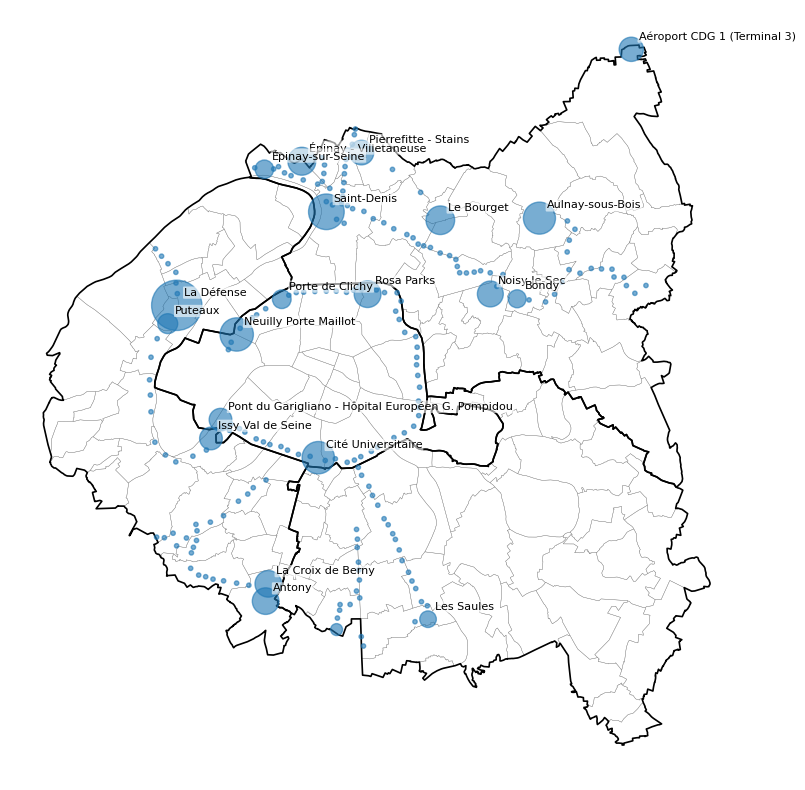

In [23]:
# Test : affichage des arrets de tramway de la petite couronne avec plus de 100 passages par jour

# fond de carte
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
deps_pc.boundary.plot(ax=ax, linewidth=1.2, edgecolor="black", zorder=2)
coms_pc.boundary.plot(ax=ax, linewidth=0.25, edgecolor="gray", zorder=1, alpha=0.9)

# créer un GeoDataFrame pour les gares puis ne garder que celles situées dans les communes de la petite couronne
gares_a_afficher = passage_par_arret[passage_par_arret["nb_tramway_per_day"] > 1]
gares_gdf = gpd.GeoDataFrame(gares_a_afficher.copy(),
                             geometry=gpd.points_from_xy(gares_a_afficher["stop_lon"], gares_a_afficher["stop_lat"]),
                             crs=4326)

gares_pc_only = gpd.sjoin(gares_gdf, coms_pc[['INSEE_COM', 'geometry']], how='inner', predicate='within')

# affichage des gares filtrées
ax.scatter(gares_pc_only["stop_lon"], gares_pc_only["stop_lat"],
           s=gares_pc_only["nb_train_per_day"]+10, alpha=0.6, zorder=3, cmap='copper')

# afficher des labels (on ne liste que les 20 gares les plus fréquentées pour éviter la surcharge)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
dx = (x1 - x0) * 0.01
dy = (y1 - y0) * 0.01

to_label = gares_pc_only.sort_values("nb_train_per_day", ascending=False).head(20)
for _, r in to_label.iterrows():
    ax.text(
        r["stop_lon"] + dx,
        r["stop_lat"] + dy,
        r["stop_name"],
        fontsize=8,
        zorder=5,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, linewidth=0)
    )

ax.set_axis_off()
# gares_pc_only.explore()